Unstructured Receipt Images to Structured Data
using PaddleOCR + NLP
(CORD Dataset)

In [1]:
%pip install -q "python-doctr[torch]" python-dateutil rapidfuzz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.1 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 60.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.9/288.9 kB 16.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


**Trial Computer Vision**

In [6]:
"""
CORD Receipt -> Grand Total Extraction (v5, classic CV + "largest number" heuristic)
=======================================================================================
Kaggle (or Colab) notebook script.

Based on the "Receipt OCR with OpenCV" two-part approach:
  Part 1: locate the receipt contour, crop, restore perspective, and apply a
          black/white "scanner" threshold effect.
  Part 2: run Tesseract OCR on the scanned image, then take the LARGEST
          well-formatted number found as the grand total -- no keyword
          matching, no "TOTAL" vs "SUB TOTAL" vs "TOTAL ITEMS" ambiguity to
          get wrong.

Adapted for CORD:
  - Contour detection can fail on some photos (no clean 4-point rectangle
    found -- crumpled paper, cut-off edges, etc). When that happens we fall
    back to using the original image directly rather than crashing or
    skipping the receipt.
  - If a receipt's ground-truth JSON has no total field at all, that
    receipt is EXCLUDED from the accuracy calculation (not counted as
    wrong) but its prediction is still computed and saved. Coverage is
    reported separately so you can see how often this happens.

"""

import re
import json
import time
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
from PIL import Image
import pytesseract
from skimage.filters import threshold_local
from tqdm import tqdm

# ---------------------------------------------------------------------------
# 1. Dataset paths -- adjust for Kaggle vs Colab as needed
# ---------------------------------------------------------------------------
DATASET = Path("/kaggle/input/datasets/aqqqrfs/cord-dataset/CORD")
OUTPUT_DIR = Path("/kaggle/working")
# For Colab instead, use e.g.:
# DATASET = Path("/content/cord-dataset/CORD")
# OUTPUT_DIR = Path("/content")


def load_split(split):
    image_dir = DATASET / split / "image"
    json_dir = DATASET / split / "json"

    images = sorted(image_dir.glob("*.png"))
    jsons = sorted(json_dir.glob("*.json"))
    json_map = {j.stem: j for j in jsons}

    matched_images, matched_jsons = [], []
    for img in images:
        if img.stem in json_map:
            matched_images.append(img)
            matched_jsons.append(json_map[img.stem])

    print(f"{split}: images={len(images)} jsons={len(jsons)} matched={len(matched_images)}")
    return matched_images, matched_jsons


train_images, train_jsons = load_split("train")
dev_images, dev_jsons = load_split("dev")
test_images, test_jsons = load_split("test")

print("\nFinal dataset sizes:")
print("Train:", len(train_images))
print("Dev:", len(dev_images))
print("Test:", len(test_images))

# Quick sanity-check toggle -- set to a small number first to confirm the
# pipeline runs end to end before committing to the full dataset.
SAMPLE_SIZE = None  # e.g. SAMPLE_SIZE = 10

if SAMPLE_SIZE is not None:
    train_images, train_jsons = train_images[:SAMPLE_SIZE], train_jsons[:SAMPLE_SIZE]
    dev_images, dev_jsons = dev_images[:SAMPLE_SIZE], dev_jsons[:SAMPLE_SIZE]
    test_images, test_jsons = test_images[:SAMPLE_SIZE], test_jsons[:SAMPLE_SIZE]
    print(f"\n[SAMPLE MODE] Using only {SAMPLE_SIZE} images per split.")


# ---------------------------------------------------------------------------
# 2. Perspective restoration (contour detection -> crop -> warp -> scan effect)
# ---------------------------------------------------------------------------
def opencv_resize(image, ratio):
    width = int(image.shape[1] * ratio)
    height = int(image.shape[0] * ratio)
    return cv2.resize(image, (width, height), interpolation=cv2.INTER_AREA)


def approximate_contour(contour):
    peri = cv2.arcLength(contour, True)
    return cv2.approxPolyDP(contour, 0.032 * peri, True)


def get_receipt_contour(contours):
    for c in contours:
        approx = approximate_contour(c)
        if len(approx) == 4:
            return approx
    return None


def contour_to_rect(contour, resize_ratio):
    pts = contour.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect / resize_ratio


def warp_perspective(img, rect):
    (tl, tr, br, bl) = rect
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))
    maxHeight = max(int(heightA), int(heightB))
    if maxWidth == 0 or maxHeight == 0:
        return None
    dst = np.array(
        [[0, 0], [maxWidth - 1, 0], [maxWidth - 1, maxHeight - 1], [0, maxHeight - 1]],
        dtype="float32",
    )
    M = cv2.getPerspectiveTransform(rect, dst)
    return cv2.warpPerspective(img, M, (maxWidth, maxHeight))


def bw_scanner(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    T = threshold_local(gray, 21, offset=5, method="gaussian")
    return (gray > T).astype("uint8") * 255


def restore_perspective(image_path: Path):
    """Returns (scanned_bw_image, contour_found: bool)."""
    original = cv2.imread(str(image_path))
    if original is None:
        return None, False

    resize_ratio = 500 / original.shape[0]
    image = opencv_resize(original, resize_ratio)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    dilated = cv2.dilate(blurred, rectKernel)
    edged = cv2.Canny(dilated, 100, 200, apertureSize=3)

    contours, _ = cv2.findContours(edged, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]
    receipt_contour = get_receipt_contour(largest_contours)

    if receipt_contour is not None:
        rect = contour_to_rect(receipt_contour, resize_ratio)
        scanned = warp_perspective(original.copy(), rect)
        if scanned is not None:
            return bw_scanner(scanned), True

    # Fallback: no clean 4-point contour found (crumpled paper, cropped
    # edges, etc). Use the original image directly rather than failing.
    return bw_scanner(original), False


# ---------------------------------------------------------------------------
# 3. OCR + grand total = largest formatted number heuristic
# ---------------------------------------------------------------------------
# CORD receipts are Indonesian Rupiah-style: comma-thousands, no decimals
# (e.g. "174,600"), unlike the original notebook's decimal-currency regex
# ("14.00"). This matches both styles so it generalizes a bit further.
AMOUNT_RE = re.compile(r"\d{1,3}(?:[.,]\d{3})+(?:[.,]\d{1,2})?|\d+[.,]\d{2}\b")


def parse_amount(raw: str):
    """Convert a matched amount string to a float, handling both
    comma-thousands ("174,600" -> 174600) and decimal ("14.00" -> 14.00)
    conventions based on which separator looks like a thousands grouping."""
    raw = raw.strip()
    # Decimal currency like "14.00" or "11.57" (exactly 2 digits after a
    # single separator, no repeated grouping) -> treat as decimal point.
    if re.fullmatch(r"\d+[.,]\d{2}", raw):
        return float(raw.replace(",", "."))
    # Thousands-grouped integer like "174,600" or "1.234.567" -> strip
    # all separators and read as a plain integer.
    digits = re.sub(r"[.,]", "", raw)
    try:
        return float(digits)
    except ValueError:
        return None


def extract_grand_total(text: str):
    matches = AMOUNT_RE.findall(text)
    amounts = [parse_amount(m) for m in matches]
    amounts = [a for a in amounts if a is not None]
    if not amounts:
        return None
    return max(amounts)


def run_ocr(image) -> str:
    pil_img = Image.fromarray(image)
    return pytesseract.image_to_string(pil_img, config="--psm 6")


# ---------------------------------------------------------------------------
# 4. Ground truth total (returns None if the receipt has no total field)
# ---------------------------------------------------------------------------
def load_gt_total(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for entry in data.get("valid_line", []):
        if entry.get("category") == "total.total_price":
            words = entry.get("words", [])
            texts = [w.get("text", "") for w in words if w.get("is_key", 0) != 1]
            joined = " ".join(t for t in texts if t)
            return parse_amount(re.sub(r"[^\d.,]", "", joined)) if joined else None
    return None  # no total.total_price category present in this receipt


# ---------------------------------------------------------------------------
# 5. Build results -- runs and saves regardless of whether GT total exists
# ---------------------------------------------------------------------------
def build_results(images, jsons, split_name):
    records = []
    times = []
    contour_found_count = 0

    for img_path, json_path in tqdm(list(zip(images, jsons)), desc=f"CV+OCR [{split_name}]", unit="img"):
        t0 = time.time()
        scanned, contour_found = restore_perspective(img_path)
        if contour_found:
            contour_found_count += 1

        if scanned is None:
            ocr_text = ""
            pred_total = None
        else:
            ocr_text = run_ocr(scanned)
            pred_total = extract_grand_total(ocr_text)

        times.append(time.time() - t0)
        gt_total = load_gt_total(json_path)

        records.append(
            {
                "image_id": img_path.stem,
                "split": split_name,
                "contour_found": contour_found,
                "pred_total": pred_total,
                "gt_total": gt_total,  # None if this receipt's JSON has no total
                "has_gt_total": gt_total is not None,
                "abs_error": (
                    abs(pred_total - gt_total)
                    if (pred_total is not None and gt_total is not None)
                    else None
                ),
                "ocr_text": ocr_text,
            }
        )

    if times:
        print(f"[{split_name}] avg {sum(times) / len(times):.2f}s/image, "
              f"contour found on {contour_found_count}/{len(images)} images")

    return pd.DataFrame(records)


# ---------------------------------------------------------------------------
# 6. Scoring -- excludes receipts with no GT total from accuracy, but keeps
#    them in the saved results and reports coverage + other scores instead
# ---------------------------------------------------------------------------
def score(df, tol=0.01):
    scored = df[df["has_gt_total"]].copy()
    n_total = len(df)
    n_scored = len(scored)

    if n_scored == 0:
        return {
            "n_samples": n_total,
            "n_with_gt_total": 0,
            "gt_coverage": 0.0,
            "accuracy": None,
            "mean_abs_error": None,
            "median_abs_error": None,
            "mean_pred_missing_rate": (df["pred_total"].isna().mean()),
        }

    scored["is_match"] = scored["abs_error"] <= tol
    accuracy = scored["is_match"].mean()

    return {
        "n_samples": n_total,
        "n_with_gt_total": n_scored,
        "gt_coverage": n_scored / n_total,
        "accuracy": accuracy,
        "mean_abs_error": scored["abs_error"].mean(),
        "median_abs_error": scored["abs_error"].median(),
        "mean_pred_missing_rate": df["pred_total"].isna().mean(),
    }


# ---------------------------------------------------------------------------
# 7. Run everything and save, no matter what
# ---------------------------------------------------------------------------
print("\n--- Running CV perspective restoration + OCR + largest-number heuristic ---")
train_df = build_results(train_images, train_jsons, "train")
dev_df = build_results(dev_images, dev_jsons, "dev")
test_df = build_results(test_images, test_jsons, "test")

full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
full_df.to_csv(OUTPUT_DIR / "cord_cv_largest_total_results.csv", index=False)
print(f"\nSaved full results ({full_df.shape}) -> {OUTPUT_DIR / 'cord_cv_largest_total_results.csv'}")

print("\n=== Scores: Train ===")
print(score(train_df))
print("\n=== Scores: Dev ===")
print(score(dev_df))
print("\n=== Scores: Test ===")
print(score(test_df))

score_summary = pd.DataFrame(
    [
        {"split": "train", **score(train_df)},
        {"split": "dev", **score(dev_df)},
        {"split": "test", **score(test_df)},
    ]
)
score_summary.to_csv(OUTPUT_DIR / "cord_cv_largest_total_scores.csv", index=False)
print(f"\nSaved score summary -> {OUTPUT_DIR / 'cord_cv_largest_total_scores.csv'}")

print(
    "\nNotes:\n"
    "  - 'gt_coverage' = fraction of receipts whose ground-truth JSON actually\n"
    "    had a total.total_price field. Receipts without one are NOT counted\n"
    "    in 'accuracy', but their predictions are still saved in the CSV.\n"
    "  - 'mean_pred_missing_rate' = how often the heuristic found NO numbers\n"
    "    at all in the OCR text (OCR failure, not a scoring gap).\n"
    "  - 'contour_found' column shows whether perspective restoration\n"
    "    actually located a 4-point receipt contour, or fell back to the\n"
    "    original (unwarped) image.\n"
)

train: images=745 jsons=787 matched=733
dev: images=94 jsons=97 matched=91
test: images=93 jsons=100 matched=93

Final dataset sizes:
Train: 733
Dev: 91
Test: 93

--- Running CV perspective restoration + OCR + largest-number heuristic ---


CV+OCR [train]: 100%|██████████| 733/733 [42:36<00:00,  3.49s/img]  


[train] avg 3.48s/image, contour found on 322/733 images


CV+OCR [dev]: 100%|██████████| 91/91 [09:42<00:00,  6.40s/img]


[dev] avg 6.39s/image, contour found on 33/91 images


CV+OCR [test]: 100%|██████████| 93/93 [05:04<00:00,  3.28s/img]


[test] avg 3.27s/image, contour found on 37/93 images

Saved full results ((917, 8)) -> /kaggle/working/cord_cv_largest_total_results.csv

=== Scores: Train ===
{'n_samples': 733, 'n_with_gt_total': 702, 'gt_coverage': 0.9577080491132333, 'accuracy': np.float64(0.1467236467236467), 'mean_abs_error': np.float64(2886478.177162162), 'median_abs_error': 17136.0, 'mean_pred_missing_rate': np.float64(0.4815825375170532)}

=== Scores: Dev ===
{'n_samples': 91, 'n_with_gt_total': 86, 'gt_coverage': 0.945054945054945, 'accuracy': np.float64(0.19767441860465115), 'mean_abs_error': np.float64(84104.56280000001), 'median_abs_error': 7749.07, 'mean_pred_missing_rate': np.float64(0.42857142857142855)}

=== Scores: Test ===
{'n_samples': 93, 'n_with_gt_total': 82, 'gt_coverage': 0.8817204301075269, 'accuracy': np.float64(0.06097560975609756), 'mean_abs_error': np.float64(385142.5848888889), 'median_abs_error': 31400.0, 'mean_pred_missing_rate': np.float64(0.45161290322580644)}

Saved score summary ->

**Trial DocTR**

In [5]:
"""
CORD Receipt OCR -> Structured Data Pipeline (v3, docTR engine) 
=================================================================
Kaggle notebook script.

"""

import re
import json
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from dateutil import parser as dateparser
from dateutil.parser import ParserError
from rapidfuzz import fuzz

# ---------------------------------------------------------------------------
# 1. Dataset paths
# ---------------------------------------------------------------------------
DATASET = Path("/kaggle/input/datasets/aqqqrfs/cord-dataset/CORD")


def load_split(split):
    image_dir = DATASET / split / "image"
    json_dir = DATASET / split / "json"

    images = sorted(image_dir.glob("*.png"))
    jsons = sorted(json_dir.glob("*.json"))

    json_map = {j.stem: j for j in jsons}

    matched_images = []
    matched_jsons = []

    missing_json = []
    for img in images:
        if img.stem in json_map:
            matched_images.append(img)
            matched_jsons.append(json_map[img.stem])
        else:
            missing_json.append(img.name)

    missing_image = []
    image_stems = {img.stem for img in images}
    for j in jsons:
        if j.stem not in image_stems:
            missing_image.append(j.name)

    print(f"{split}:")
    print(f"  Images found: {len(images)}")
    print(f"  JSONs found : {len(jsons)}")
    print(f"  Matched     : {len(matched_images)}")

    if missing_json:
        print(f"  Missing JSON ({len(missing_json)}):", missing_json[:5])
    if missing_image:
        print(f"  Missing images ({len(missing_image)}):", missing_image[:5])

    return matched_images, matched_jsons


train_images, train_jsons = load_split("train")
dev_images, dev_jsons = load_split("dev")
test_images, test_jsons = load_split("test")

print("\nFinal dataset sizes:")
print("Train:", len(train_images))
print("Dev:", len(dev_images))
print("Test:", len(test_images))


# ---------------------------------------------------------------------------
# 2. docTR OCR engine (singleton) + preprocessing
# ---------------------------------------------------------------------------
_DOCTR_PREDICTOR = None


def get_doctr_predictor():
    """Lazy singleton so the (large) pretrained weights load only once
    per Kaggle session, not once per image."""
    global _DOCTR_PREDICTOR
    if _DOCTR_PREDICTOR is None:
        from doctr.models import ocr_predictor
        _DOCTR_PREDICTOR = ocr_predictor(
            det_arch="db_resnet50",
            reco_arch="crnn_vgg16_bn",
            pretrained=True,
        )
    return _DOCTR_PREDICTOR


def preprocess_for_doctr(image_path):
    """Upscale + CLAHE contrast only -- NO binarization.

    Unlike Tesseract, docTR's detection/recognition nets are CNNs trained
    on natural (color, non-binarized) document images. Hard-thresholding
    to black/white (which helped Tesseract) tends to destroy texture cues
    these models rely on, so we keep the image in color and only fix
    contrast/scale, which matters for the faded thermal-print receipts
    in this dataset.
    """
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Upscale -- small/faded text benefits from more pixels
    img = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

    # CLAHE on the L channel (LAB space) boosts local contrast without
    # blowing out color channels the way a naive global stretch would
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_channel = clahe.apply(l_channel)
    lab = cv2.merge((l_channel, a_channel, b_channel))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return img


def run_ocr(image_path: Path, use_preprocessing: bool = True) -> str:
    """Extract raw text from a receipt image using docTR.

    docTR groups detections into pages -> blocks -> lines -> words with
    geometry already resolved, so reconstructing reading-order text is
    just walking that structure (no risk of Tesseract's page-segmentation
    quirks merging/splitting rows unpredictably).
    """
    predictor = get_doctr_predictor()

    if use_preprocessing:
        img = preprocess_for_doctr(image_path)
    else:
        img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)

    result = predictor([img])
    export = result.export()

    lines_text = []
    for page in export["pages"]:
        for block in page["blocks"]:
            for line in block["lines"]:
                words = [w["value"] for w in line["words"]]
                if words:
                    lines_text.append(" ".join(words))

    return "\n".join(lines_text)


# ---------------------------------------------------------------------------
# 3. Cleaning
# ---------------------------------------------------------------------------
def clean_text(raw_text: str) -> list:
    lines = [l.strip() for l in raw_text.split("\n")]
    lines = [re.sub(r"\s+", " ", l) for l in lines if l.strip()]
    return lines


# ---------------------------------------------------------------------------
# 4. Entity extraction (rule-based NLP)
# ---------------------------------------------------------------------------
MONEY_RE = re.compile(r"(\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})|\d+[.,]\d{2}|\d+)")
TOTAL_KEYWORDS = ["grand total", "total due", "amount due", "total"]

# FIX (carried over from v2): "total" is a substring of "subtotal", so a
# plain substring check on TOTAL_KEYWORDS misfires on SUB_TOTAL lines.
# Word-boundary regex + explicit exclusion prevents that.
EXCLUDE_FROM_TOTAL = ["sub total", "sub_total", "subtotal", "discount"]
SKIP_KEYWORDS = TOTAL_KEYWORDS + EXCLUDE_FROM_TOTAL + ["tax", "cash", "change", "vat"]
DATE_RE = re.compile(r"(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}|\d{4}[/\-.]\d{1,2}[/\-.]\d{1,2})")


def normalize_amount(s):
    if s is None:
        return None
    s = str(s).replace(",", "").strip()
    try:
        return float(s)
    except ValueError:
        return None


def normalize_date(s):
    if not s:
        return None
    try:
        dt = dateparser.parse(str(s), fuzzy=True, dayfirst=False)
        return dt.strftime("%Y-%m-%d")
    except (ParserError, ValueError, OverflowError, TypeError):
        return None


def extract_date(lines):
    for l in lines:
        m = DATE_RE.search(l)
        if m:
            norm = normalize_date(m.group(1))
            if norm:
                return norm
    return None


def extract_total(lines):
    """Word-boundary matching + explicit exclusion of subtotal/discount
    lines, so 'SUB_TOTAL 194,000' can't be picked up as the grand total
    just because it contains the substring 'total'."""
    candidates = []
    for l in lines:
        low = l.lower().replace("_", " ")

        if any(ex in low for ex in EXCLUDE_FROM_TOTAL):
            continue

        for kw in TOTAL_KEYWORDS:
            if re.search(rf"\b{re.escape(kw)}\b", low):
                amounts = MONEY_RE.findall(l)
                if amounts:
                    candidates.append((kw, normalize_amount(amounts[-1])))

    if not candidates:
        return None

    for kw in ["grand total", "total due", "amount due", "total"]:
        for c_kw, val in candidates:
            if c_kw == kw and val is not None:
                return val
    return None


def extract_store_name(lines):
    """Heuristic: first line that isn't a date or pure numeric string."""
    for l in lines[:3]:
        if not DATE_RE.search(l) and not re.fullmatch(r"[\d\s.,-]+", l):
            return l
    return lines[0] if lines else None


def extract_items(lines):
    items = []
    for l in lines:
        low = l.lower().replace("_", " ")
        if any(kw in low for kw in SKIP_KEYWORDS):
            continue
        m = MONEY_RE.findall(l)
        if not m:
            continue
        price = normalize_amount(m[-1])
        if price is None:
            continue
        name_part = MONEY_RE.sub("", l).strip(" -:.")
        if name_part:
            items.append({"name": name_part, "price": price})
    return items


def extract_entities(raw_text):
    lines = clean_text(raw_text)
    return {
        "store_name": extract_store_name(lines),
        "date": extract_date(lines),
        "total": extract_total(lines),
        "items": extract_items(lines),
    }


# ---------------------------------------------------------------------------
# 5. Ground truth loading (+ full text reconstruction for CER/WER + ablation)
# ---------------------------------------------------------------------------
def _entry_text(entry, values_only=True):
    words = entry.get("words", [])
    texts = []
    for w in words:
        if values_only and w.get("is_key", 0) == 1:
            continue
        t = w.get("text", "")
        if t:
            texts.append(t)
    return " ".join(texts).strip()


def load_ground_truth(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    valid_lines = data.get("valid_line", [])

    groups = {}
    for entry in valid_lines:
        gid = entry.get("group_id")
        groups.setdefault(gid, []).append(entry)

    items = []
    total_price = None

    for gid, entries in groups.items():
        cat_map = {}
        for e in entries:
            cat = e.get("category", "")
            cat_map[cat] = _entry_text(e)

        if "menu.nm" in cat_map or "menu.price" in cat_map:
            nm = cat_map.get("menu.nm")
            price = normalize_amount(cat_map.get("menu.price"))
            if nm:
                items.append({"name": nm, "price": price})

        if "total.total_price" in cat_map:
            total_price = normalize_amount(cat_map["total.total_price"])

    return {
        "date": None,  # this schema has no date category
        "total": total_price,
        "items": items,
    }


def reconstruct_gt_full_text(json_path: Path) -> str:
    """Rebuild plain text from ground-truth word tokens (grouped by
    row_id, in original word order, including key tokens). Used for
    CER/WER measurement and for the parsing-logic ablation."""
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    valid_lines = data.get("valid_line", [])

    rows = {}
    for entry in valid_lines:
        for w in entry.get("words", []):
            rid = w.get("row_id")
            rows.setdefault(rid, []).append(w.get("text", ""))

    lines = [" ".join(rows[rid]) for rid in sorted(rows.keys())]
    return "\n".join(lines)


# ---------------------------------------------------------------------------
# 6. CER / WER (no extra dependency -- simple Levenshtein distance)
# ---------------------------------------------------------------------------
def levenshtein(a, b):
    n, m = len(a), len(b)
    if n == 0:
        return m
    if m == 0:
        return n
    prev = list(range(m + 1))
    for i in range(1, n + 1):
        curr = [i] + [0] * m
        for j in range(1, m + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            curr[j] = min(
                prev[j] + 1,
                curr[j - 1] + 1,
                prev[j - 1] + cost,
            )
        prev = curr
    return prev[m]


def cer(hypothesis: str, reference: str) -> float:
    ref_chars = list(reference.replace("\n", " "))
    hyp_chars = list(hypothesis.replace("\n", " "))
    if not ref_chars:
        return None
    return levenshtein(hyp_chars, ref_chars) / len(ref_chars)


def wer(hypothesis: str, reference: str) -> float:
    ref_words = reference.split()
    hyp_words = hypothesis.split()
    if not ref_words:
        return None
    return levenshtein(hyp_words, ref_words) / len(ref_words)


# ---------------------------------------------------------------------------
# 7. Build structured dataset (OCR path) + ablation (GT-text path)
# ---------------------------------------------------------------------------
def build_dataset(images, jsons, split_name, use_preprocessing=True):
    records = []
    for img_path, json_path in zip(images, jsons):
        raw_text = run_ocr(img_path, use_preprocessing=use_preprocessing)
        pred = extract_entities(raw_text)
        gt = load_ground_truth(json_path)
        gt_full_text = reconstruct_gt_full_text(json_path)

        records.append(
            {
                "image_id": img_path.stem,
                "split": split_name,
                "ocr_text": raw_text,
                "pred_store_name": pred["store_name"],
                "pred_date": pred["date"],
                "pred_total": pred["total"],
                "pred_items": json.dumps(pred["items"]),
                "gt_date": gt["date"],
                "gt_total": gt["total"],
                "gt_items": json.dumps(gt["items"]),
                "cer": cer(raw_text, gt_full_text),
                "wer": wer(raw_text, gt_full_text),
            }
        )
    return pd.DataFrame(records)


def build_ablation_dataset(images, jsons, split_name):
    records = []
    for img_path, json_path in zip(images, jsons):
        gt_full_text = reconstruct_gt_full_text(json_path)
        pred = extract_entities(gt_full_text)
        gt = load_ground_truth(json_path)

        records.append(
            {
                "image_id": img_path.stem,
                "split": split_name,
                "pred_total": pred["total"],
                "pred_items": json.dumps(pred["items"]),
                "gt_total": gt["total"],
                "gt_items": json.dumps(gt["items"]),
            }
        )
    return pd.DataFrame(records)


# ---------------------------------------------------------------------------
# 8. Evaluation
# ---------------------------------------------------------------------------
def amounts_match(a, b, tol=0.01):
    if a is None or b is None:
        return False
    return abs(a - b) <= tol


def dates_match(a, b):
    return a is not None and b is not None and a == b


def items_prf(pred_items, gt_items, price_tol=0.01, name_thresh=70):
    if not gt_items and not pred_items:
        return 1.0, 1.0, 1.0
    matched_gt = set()
    tp = 0
    for p in pred_items:
        for i, g in enumerate(gt_items):
            if i in matched_gt:
                continue
            price_ok = amounts_match(p["price"], g["price"], price_tol)
            name_ok = fuzz.token_set_ratio(str(p["name"]), str(g["name"])) >= name_thresh
            if price_ok and name_ok:
                matched_gt.add(i)
                tp += 1
                break
    precision = tp / len(pred_items) if pred_items else 0.0
    recall = tp / len(gt_items) if gt_items else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def evaluate(df):
    date_hits, total_hits = 0, 0
    date_total, total_total = 0, 0
    precisions, recalls, f1s = [], [], []

    has_date_col = "gt_date" in df.columns

    for _, row in df.iterrows():
        if has_date_col:
            gt_date = row["gt_date"]
            if gt_date:
                date_total += 1
                if dates_match(row["pred_date"], gt_date):
                    date_hits += 1

        gt_total = row["gt_total"]
        if gt_total is not None:
            total_total += 1
            if amounts_match(row["pred_total"], gt_total):
                total_hits += 1

        pred_items = json.loads(row["pred_items"])
        gt_items = json.loads(row["gt_items"])
        p, r, f1 = items_prf(pred_items, gt_items)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    result = {
        "total_accuracy": total_hits / total_total if total_total else None,
        "item_precision_avg": sum(precisions) / len(precisions) if precisions else None,
        "item_recall_avg": sum(recalls) / len(recalls) if recalls else None,
        "item_f1_avg": sum(f1s) / len(f1s) if f1s else None,
        "n_samples": len(df),
    }
    if has_date_col:
        result["date_accuracy"] = date_hits / date_total if date_total else None
    return result


# ---------------------------------------------------------------------------
# 9. Run everything
# ---------------------------------------------------------------------------
print("\n--- Running OCR pipeline (docTR, with preprocessing) ---")
train_df = build_dataset(train_images, train_jsons, "train")
dev_df = build_dataset(dev_images, dev_jsons, "dev")
test_df = build_dataset(test_images, test_jsons, "test")

full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
full_df.to_csv("/kaggle/working/cord_structured_output.csv", index=False)
print("Saved structured CSV:", full_df.shape)

print("\n=== OCR-based Evaluation: Train ===")
print(evaluate(train_df))
print("\n=== OCR-based Evaluation: Dev ===")
print(evaluate(dev_df))
print("\n=== OCR-based Evaluation: Test ===")
print(evaluate(test_df))

print("\n--- OCR quality (CER / WER vs ground truth text) ---")
for name, d in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    print(f"{name}: mean CER = {d['cer'].mean():.3f}, mean WER = {d['wer'].mean():.3f}")

eval_summary = pd.DataFrame(
    [
        {"split": "train", **evaluate(train_df)},
        {"split": "dev", **evaluate(dev_df)},
        {"split": "test", **evaluate(test_df)},
    ]
)
eval_summary.to_csv("/kaggle/working/cord_eval_summary.csv", index=False)
print("\nSaved evaluation summary CSV -> /kaggle/working/cord_eval_summary.csv")

# ---------------------------------------------------------------------------
# 10. Ablation: same parsing logic on ground-truth text (isolates OCR loss
#     from parsing-logic loss)
# ---------------------------------------------------------------------------
print("\n--- Running ablation (parsing logic on GROUND-TRUTH text, no OCR) ---")
train_abl = build_ablation_dataset(train_images, train_jsons, "train")
dev_abl = build_ablation_dataset(dev_images, dev_jsons, "dev")
test_abl = build_ablation_dataset(test_images, test_jsons, "test")

print("\n=== Ablation Evaluation: Train (GT text, not OCR) ===")
print(evaluate(train_abl))
print("\n=== Ablation Evaluation: Dev (GT text, not OCR) ===")
print(evaluate(dev_abl))
print("\n=== Ablation Evaluation: Test (GT text, not OCR) ===")
print(evaluate(test_abl))

ablation_summary = pd.DataFrame(
    [
        {"split": "train", **evaluate(train_abl)},
        {"split": "dev", **evaluate(dev_abl)},
        {"split": "test", **evaluate(test_abl)},
    ]
)
ablation_summary.to_csv("/kaggle/working/cord_ablation_summary.csv", index=False)
print("\nSaved ablation summary CSV -> /kaggle/working/cord_ablation_summary.csv")

print(
    "\nInterpretation guide:\n"
    "  - If ablation total_accuracy/item_f1 is MUCH higher than the OCR-based\n"
    "    run -> OCR quality (see mean CER/WER above) is the main bottleneck.\n"
    "  - If ablation scores are ALSO low -> the parsing/regex logic itself\n"
    "    needs work, independent of OCR.\n"
    "  - Compare this run's mean CER/WER against the Tesseract version's to\n"
    "    see how much docTR actually improved raw OCR quality on this dataset.\n"
)

train:
  Images found: 745
  JSONs found : 787
  Matched     : 733
  Missing JSON (12): ['receipt_00005.png', 'receipt_00061.png', 'receipt_00068.png', 'receipt_00075.png', 'receipt_00118.png']
  Missing images (54): ['receipt_00000.json', 'receipt_00040.json', 'receipt_00049.json', 'receipt_00058.json', 'receipt_00089.json']
dev:
  Images found: 94
  JSONs found : 97
  Matched     : 91
  Missing JSON (3): ['receipt_00036.png', 'receipt_00049.png', 'receipt_00094.png']
  Missing images (6): ['receipt_00028.json', 'receipt_00054.json', 'receipt_00055.json', 'receipt_00057.json', 'receipt_00092.json']
test:
  Images found: 93
  JSONs found : 100
  Matched     : 93
  Missing images (7): ['receipt_00001.json', 'receipt_00015.json', 'receipt_00044.json', 'receipt_00046.json', 'receipt_00054.json']

Final dataset sizes:
Train: 733
Dev: 91
Test: 93

--- Running OCR pipeline (docTR, with preprocessing) ---


  0%|          | 0/102021912 [00:00<?, ?it/s]

  0%|          | 0/63303144 [00:00<?, ?it/s]

Saved structured CSV: (917, 12)

=== OCR-based Evaluation: Train ===
{'total_accuracy': 0.0, 'item_precision_avg': 0.00893587994542974, 'item_recall_avg': 0.00907880205288118, 'item_f1_avg': 0.00889365295913727, 'n_samples': 733, 'date_accuracy': None}

=== OCR-based Evaluation: Dev ===
{'total_accuracy': 0.0, 'item_precision_avg': 0.0, 'item_recall_avg': 0.0, 'item_f1_avg': 0.0, 'n_samples': 91, 'date_accuracy': None}

=== OCR-based Evaluation: Test ===
{'total_accuracy': 0.0, 'item_precision_avg': 0.008064516129032258, 'item_recall_avg': 0.010752688172043012, 'item_f1_avg': 0.008960573476702509, 'n_samples': 93, 'date_accuracy': None}

--- OCR quality (CER / WER vs ground truth text) ---
train: mean CER = 0.131, mean WER = 0.289
dev: mean CER = 0.154, mean WER = 0.335
test: mean CER = 0.146, mean WER = 0.295

Saved evaluation summary CSV -> /kaggle/working/cord_eval_summary.csv

--- Running ablation (parsing logic on GROUND-TRUTH text, no OCR) ---

=== Ablation Evaluation: Train (GT 

In [2]:
"""
CORD Receipt OCR -> Structured Data Pipeline (with Evaluation)
================================================================
Kaggle notebook script.

Pipeline
--------
1. Load CORD dataset (train/dev/test) images + ground-truth JSON annotations.
2. OCR extraction using pytesseract.
3. Text cleaning / normalization.
4. Rule-based entity extraction: store name, date, line items, total.
5. Export structured predictions to CSV.
6. Evaluate predictions against CORD ground truth (gt_parse) with
   per-field accuracy, item-level precision/recall/F1, and an overall report.

Setup (run once in a Kaggle cell before this script):
    !apt-get update -qq && apt-get install -y tesseract-ocr -qq
    !pip install pytesseract python-dateutil rapidfuzz -q
"""

import re
import json
import pandas as pd
from pathlib import Path
from dateutil import parser as dateparser
from dateutil.parser import ParserError
import pytesseract
from PIL import Image
from rapidfuzz import fuzz

# ---------------------------------------------------------------------------
# 1. Dataset paths
# ---------------------------------------------------------------------------
DATASET = Path("/kaggle/input/datasets/aqqqrfs/cord-dataset/CORD")


def load_split(split):
    image_dir = DATASET / split / "image"
    json_dir = DATASET / split / "json"

    images = sorted(image_dir.glob("*.png"))
    jsons = sorted(json_dir.glob("*.json"))

    # Map JSON files by filename stem
    json_map = {j.stem: j for j in jsons}

    matched_images = []
    matched_jsons = []

    missing_json = []
    for img in images:
        if img.stem in json_map:
            matched_images.append(img)
            matched_jsons.append(json_map[img.stem])
        else:
            missing_json.append(img.name)

    missing_image = []
    image_stems = {img.stem for img in images}
    for j in jsons:
        if j.stem not in image_stems:
            missing_image.append(j.name)

    print(f"{split}:")
    print(f"  Images found: {len(images)}")
    print(f"  JSONs found : {len(jsons)}")
    print(f"  Matched     : {len(matched_images)}")

    if missing_json:
        print(f"  Missing JSON ({len(missing_json)}):", missing_json[:5])

    if missing_image:
        print(f"  Missing images ({len(missing_image)}):", missing_image[:5])

    return matched_images, matched_jsons


train_images, train_jsons = load_split("train")
dev_images, dev_jsons = load_split("dev")
test_images, test_jsons = load_split("test")

print("\nFinal dataset sizes:")
print("Train:", len(train_images))
print("Dev:", len(dev_images))
print("Test:", len(test_images))


# ---------------------------------------------------------------------------
# 2. OCR
# ---------------------------------------------------------------------------
def run_ocr(image_path: Path) -> str:
    """Extract raw text from a receipt image using Tesseract."""
    img = Image.open(image_path).convert("RGB")
    return pytesseract.image_to_string(img)


# ---------------------------------------------------------------------------
# 3. Cleaning
# ---------------------------------------------------------------------------
def clean_text(raw_text: str) -> list:
    lines = [l.strip() for l in raw_text.split("\n")]
    lines = [re.sub(r"\s+", " ", l) for l in lines if l.strip()]
    return lines


# ---------------------------------------------------------------------------
# 4. Entity extraction (rule-based NLP)
# ---------------------------------------------------------------------------
MONEY_RE = re.compile(r"(\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})|\d+[.,]\d{2}|\d+)")
TOTAL_KEYWORDS = ["grand total", "total due", "amount due", "total"]
SKIP_KEYWORDS = TOTAL_KEYWORDS + ["subtotal", "sub total", "tax", "cash", "change", "vat"]
DATE_RE = re.compile(r"(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}|\d{4}[/\-.]\d{1,2}[/\-.]\d{1,2})")


def normalize_amount(s):
    if s is None:
        return None
    s = str(s).replace(",", "").strip()
    try:
        return float(s)
    except ValueError:
        return None


def normalize_date(s):
    if not s:
        return None
    try:
        dt = dateparser.parse(str(s), fuzzy=True, dayfirst=False)
        return dt.strftime("%Y-%m-%d")
    except (ParserError, ValueError, OverflowError, TypeError):
        return None


def extract_date(lines):
    for l in lines:
        m = DATE_RE.search(l)
        if m:
            norm = normalize_date(m.group(1))
            if norm:
                return norm
    return None


def extract_total(lines):
    candidates = []
    for l in lines:
        low = l.lower()
        for kw in TOTAL_KEYWORDS:
            if kw in low:
                amounts = MONEY_RE.findall(l)
                if amounts:
                    candidates.append((kw, normalize_amount(amounts[-1])))
    if not candidates:
        return None
    # Prefer the most specific keyword match first
    for kw in ["grand total", "total due", "amount due", "total"]:
        for c_kw, val in candidates:
            if c_kw == kw and val is not None:
                return val
    return None


def extract_store_name(lines):
    """Heuristic: first line that isn't a date or pure numeric string."""
    for l in lines[:3]:
        if not DATE_RE.search(l) and not re.fullmatch(r"[\d\s.,-]+", l):
            return l
    return lines[0] if lines else None


def extract_items(lines):
    items = []
    for l in lines:
        low = l.lower()
        if any(kw in low for kw in SKIP_KEYWORDS):
            continue
        m = MONEY_RE.findall(l)
        if not m:
            continue
        price = normalize_amount(m[-1])
        if price is None:
            continue
        name_part = MONEY_RE.sub("", l).strip(" -:.")
        if name_part:
            items.append({"name": name_part, "price": price})
    return items


def extract_entities(raw_text):
    lines = clean_text(raw_text)
    return {
        "store_name": extract_store_name(lines),
        "date": extract_date(lines),
        "total": extract_total(lines),
        "items": extract_items(lines),
    }


# ---------------------------------------------------------------------------
# 5. Ground truth parsing (CORD gt_parse field)
# ---------------------------------------------------------------------------
def load_ground_truth(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    gt = data.get("gt_parse", {})

    menu = gt.get("menu", [])
    if isinstance(menu, dict):
        menu = [menu]
    items = []
    for m in menu:
        nm = m.get("nm")
        price = m.get("price") or m.get("unitprice")
        price = normalize_amount(price) if price else None
        if nm:
            items.append({"name": nm, "price": price})

    total_block = gt.get("total", {})
    total_price = normalize_amount(total_block.get("total_price"))

    # CORD's gt_parse does not always carry an explicit date field;
    # this is a best-effort fallback for the (uncommon) cases that do.
    date_val = gt.get("date")

    return {
        "date": normalize_date(date_val) if date_val else None,
        "total": total_price,
        "items": items,
    }


# ---------------------------------------------------------------------------
# 6. Build structured dataset
# ---------------------------------------------------------------------------
def build_dataset(images, jsons, split_name):
    records = []
    for img_path, json_path in zip(images, jsons):
        raw_text = run_ocr(img_path)
        pred = extract_entities(raw_text)
        gt = load_ground_truth(json_path)
        records.append(
            {
                "image_id": img_path.stem,
                "split": split_name,
                "ocr_text": raw_text,
                "pred_store_name": pred["store_name"],
                "pred_date": pred["date"],
                "pred_total": pred["total"],
                "pred_items": json.dumps(pred["items"]),
                "gt_date": gt["date"],
                "gt_total": gt["total"],
                "gt_items": json.dumps(gt["items"]),
            }        
            
        )
    return pd.DataFrame(records)


train_df = build_dataset(train_images, train_jsons, "train")
dev_df = build_dataset(dev_images, dev_jsons, "dev")
test_df = build_dataset(test_images, test_jsons, "test")

full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
full_df.to_csv("/kaggle/working/cord_structured_output.csv", index=False)
print("Saved structured CSV:", full_df.shape)


# ---------------------------------------------------------------------------
# 7. Evaluation pipeline
# ---------------------------------------------------------------------------
def amounts_match(a, b, tol=0.01):
    if a is None or b is None:
        return False
    return abs(a - b) <= tol


def dates_match(a, b):
    return a is not None and b is not None and a == b


def items_prf(pred_items, gt_items, price_tol=0.01, name_thresh=70):
    if not gt_items and not pred_items:
        return 1.0, 1.0, 1.0
    matched_gt = set()
    tp = 0
    for p in pred_items:
        for i, g in enumerate(gt_items):
            if i in matched_gt:
                continue
            price_ok = amounts_match(p["price"], g["price"], price_tol)
            name_ok = fuzz.token_set_ratio(str(p["name"]), str(g["name"])) >= name_thresh
            if price_ok and name_ok:
                matched_gt.add(i)
                tp += 1
                break
    precision = tp / len(pred_items) if pred_items else 0.0
    recall = tp / len(gt_items) if gt_items else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def evaluate(df):
    date_hits, total_hits = 0, 0
    date_total, total_total = 0, 0
    precisions, recalls, f1s = [], [], []

    for _, row in df.iterrows():
        gt_date = row["gt_date"]
        if gt_date:
            date_total += 1
            if dates_match(row["pred_date"], gt_date):
                date_hits += 1

        gt_total = row["gt_total"]
        if gt_total is not None:
            total_total += 1
            if amounts_match(row["pred_total"], gt_total):
                total_hits += 1

        pred_items = json.loads(row["pred_items"])
        gt_items = json.loads(row["gt_items"])
        p, r, f1 = items_prf(pred_items, gt_items)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return {
        "date_accuracy": date_hits / date_total if date_total else None,
        "total_accuracy": total_hits / total_total if total_total else None,
        "item_precision_avg": sum(precisions) / len(precisions) if precisions else None,
        "item_recall_avg": sum(recalls) / len(recalls) if recalls else None,
        "item_f1_avg": sum(f1s) / len(f1s) if f1s else None,
        "n_samples": len(df),
    }


print("\n=== Evaluation: Train ===")
print(evaluate(train_df))
print("\n=== Evaluation: Dev ===")
print(evaluate(dev_df))
print("\n=== Evaluation: Test ===")
print(evaluate(test_df))

eval_summary = pd.DataFrame(
    [
        {"split": "train", **evaluate(train_df)},
        {"split": "dev", **evaluate(dev_df)},
        {"split": "test", **evaluate(test_df)},
    ]
)
eval_summary.to_csv("/kaggle/working/cord_eval_summary.csv", index=False)
print("\nSaved evaluation summary CSV -> /kaggle/working/cord_eval_summary.csv")

train:
  Images found: 745
  JSONs found : 787
  Matched     : 733
  Missing JSON (12): ['receipt_00005.png', 'receipt_00061.png', 'receipt_00068.png', 'receipt_00075.png', 'receipt_00118.png']
  Missing images (54): ['receipt_00000.json', 'receipt_00040.json', 'receipt_00049.json', 'receipt_00058.json', 'receipt_00089.json']
dev:
  Images found: 94
  JSONs found : 97
  Matched     : 91
  Missing JSON (3): ['receipt_00036.png', 'receipt_00049.png', 'receipt_00094.png']
  Missing images (6): ['receipt_00028.json', 'receipt_00054.json', 'receipt_00055.json', 'receipt_00057.json', 'receipt_00092.json']
test:
  Images found: 93
  JSONs found : 100
  Matched     : 93
  Missing images (7): ['receipt_00001.json', 'receipt_00015.json', 'receipt_00044.json', 'receipt_00046.json', 'receipt_00054.json']

Final dataset sizes:
Train: 733
Dev: 91
Test: 93
Saved structured CSV: (917, 10)

=== Evaluation: Train ===
{'date_accuracy': None, 'total_accuracy': None, 'item_precision_avg': 0.371077762619372

In [3]:
"""
CORD Receipt OCR -> Structured Data Pipeline (with Evaluation)
================================================================
Kaggle notebook script.

Pipeline
--------
1. Load CORD dataset (train/dev/test) images + ground-truth JSON annotations.
2. OCR extraction using pytesseract.
3. Text cleaning / normalization.
4. Rule-based entity extraction: store name, date, line items, total.
5. Export structured predictions to CSV.
6. Evaluate predictions against CORD ground truth (gt_parse) with
   per-field accuracy, item-level precision/recall/F1, and an overall report.

Setup (run once in a Kaggle cell before this script):
    !apt-get update -qq && apt-get install -y tesseract-ocr -qq
    !pip install pytesseract python-dateutil rapidfuzz -q
"""

import re
import json
import pandas as pd
from pathlib import Path
from dateutil import parser as dateparser
from dateutil.parser import ParserError
import pytesseract
from PIL import Image
from rapidfuzz import fuzz

# ---------------------------------------------------------------------------
# 1. Dataset paths
# ---------------------------------------------------------------------------
DATASET = Path("/kaggle/input/datasets/aqqqrfs/cord-dataset/CORD")


def load_split(split):
    image_dir = DATASET / split / "image"
    json_dir = DATASET / split / "json"

    images = sorted(image_dir.glob("*.png"))
    jsons = sorted(json_dir.glob("*.json"))

    # Map JSON files by filename stem
    json_map = {j.stem: j for j in jsons}

    matched_images = []
    matched_jsons = []

    missing_json = []
    for img in images:
        if img.stem in json_map:
            matched_images.append(img)
            matched_jsons.append(json_map[img.stem])
        else:
            missing_json.append(img.name)

    missing_image = []
    image_stems = {img.stem for img in images}
    for j in jsons:
        if j.stem not in image_stems:
            missing_image.append(j.name)

    print(f"{split}:")
    print(f"  Images found: {len(images)}")
    print(f"  JSONs found : {len(jsons)}")
    print(f"  Matched     : {len(matched_images)}")

    if missing_json:
        print(f"  Missing JSON ({len(missing_json)}):", missing_json[:5])

    if missing_image:
        print(f"  Missing images ({len(missing_image)}):", missing_image[:5])

    return matched_images, matched_jsons


train_images, train_jsons = load_split("train")
dev_images, dev_jsons = load_split("dev")
test_images, test_jsons = load_split("test")

print("\nFinal dataset sizes:")
print("Train:", len(train_images))
print("Dev:", len(dev_images))
print("Test:", len(test_images))


# ---------------------------------------------------------------------------
# 2. OCR
# ---------------------------------------------------------------------------
def run_ocr(image_path: Path) -> str:
    """Extract raw text from a receipt image using Tesseract."""
    img = Image.open(image_path).convert("RGB")
    return pytesseract.image_to_string(img)


# ---------------------------------------------------------------------------
# 3. Cleaning
# ---------------------------------------------------------------------------
def clean_text(raw_text: str) -> list:
    lines = [l.strip() for l in raw_text.split("\n")]
    lines = [re.sub(r"\s+", " ", l) for l in lines if l.strip()]
    return lines


# ---------------------------------------------------------------------------
# 4. Entity extraction (rule-based NLP)
# ---------------------------------------------------------------------------
MONEY_RE = re.compile(r"(\d{1,3}(?:[.,]\d{3})*(?:[.,]\d{2})|\d+[.,]\d{2}|\d+)")
TOTAL_KEYWORDS = ["grand total", "total due", "amount due", "total"]
SKIP_KEYWORDS = TOTAL_KEYWORDS + ["subtotal", "sub total", "tax", "cash", "change", "vat"]
DATE_RE = re.compile(r"(\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}|\d{4}[/\-.]\d{1,2}[/\-.]\d{1,2})")


def normalize_amount(s):
    if s is None:
        return None
    s = str(s).replace(",", "").strip()
    try:
        return float(s)
    except ValueError:
        return None


def normalize_date(s):
    if not s:
        return None
    try:
        dt = dateparser.parse(str(s), fuzzy=True, dayfirst=False)
        return dt.strftime("%Y-%m-%d")
    except (ParserError, ValueError, OverflowError, TypeError):
        return None


def extract_date(lines):
    for l in lines:
        m = DATE_RE.search(l)
        if m:
            norm = normalize_date(m.group(1))
            if norm:
                return norm
    return None


def extract_total(lines):
    candidates = []
    for l in lines:
        low = l.lower()
        for kw in TOTAL_KEYWORDS:
            if kw in low:
                amounts = MONEY_RE.findall(l)
                if amounts:
                    candidates.append((kw, normalize_amount(amounts[-1])))
    if not candidates:
        return None
    # Prefer the most specific keyword match first
    for kw in ["grand total", "total due", "amount due", "total"]:
        for c_kw, val in candidates:
            if c_kw == kw and val is not None:
                return val
    return None


def extract_store_name(lines):
    """Heuristic: first line that isn't a date or pure numeric string."""
    for l in lines[:3]:
        if not DATE_RE.search(l) and not re.fullmatch(r"[\d\s.,-]+", l):
            return l
    return lines[0] if lines else None


def extract_items(lines):
    items = []
    for l in lines:
        low = l.lower()
        if any(kw in low for kw in SKIP_KEYWORDS):
            continue
        m = MONEY_RE.findall(l)
        if not m:
            continue
        price = normalize_amount(m[-1])
        if price is None:
            continue
        name_part = MONEY_RE.sub("", l).strip(" -:.")
        if name_part:
            items.append({"name": name_part, "price": price})
    return items


def extract_entities(raw_text):
    lines = clean_text(raw_text)
    return {
        "store_name": extract_store_name(lines),
        "date": extract_date(lines),
        "total": extract_total(lines),
        "items": extract_items(lines),
    }


def _entry_text(entry, values_only=True):
    """Join an entry's word tokens into text, optionally skipping label
    tokens (is_key=1) to get just the value (e.g. 'CHANGE 72,000' -> '72,000')."""
    words = entry.get("words", [])
    texts = []
    for w in words:
        if values_only and w.get("is_key", 0) == 1:
            continue
        t = w.get("text", "")
        if t:
            texts.append(t)
    return " ".join(texts).strip()


def load_ground_truth(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    valid_lines = data.get("valid_line", [])

    # Group entries by group_id -- entries sharing a group_id belong to
    # the same logical row (e.g. one menu item's name + price together).
    groups = {}
    for entry in valid_lines:
        gid = entry.get("group_id")
        groups.setdefault(gid, []).append(entry)

    items = []
    total_price = None

    for gid, entries in groups.items():
        cat_map = {}
        for e in entries:
            cat = e.get("category", "")
            cat_map[cat] = _entry_text(e)

        # A group with a menu name and/or price is one line item
        if "menu.nm" in cat_map or "menu.price" in cat_map:
            nm = cat_map.get("menu.nm")
            price = normalize_amount(cat_map.get("menu.price"))
            if nm:
                items.append({"name": nm, "price": price})

        # Grand total (prefer this over subtotal if both exist)
        if "total.total_price" in cat_map:
            total_price = normalize_amount(cat_map["total.total_price"])

    return {
        "date": None,  # this schema has no date category either
        "total": total_price,
        "items": items,
    }


# ---------------------------------------------------------------------------
# 6. Build structured dataset
# ---------------------------------------------------------------------------
def build_dataset(images, jsons, split_name):
    records = []
    for img_path, json_path in zip(images, jsons):
        raw_text = run_ocr(img_path)
        pred = extract_entities(raw_text)
        gt = load_ground_truth(json_path)
        records.append(
            {
                "image_id": img_path.stem,
                "split": split_name,
                "ocr_text": raw_text,
                "pred_store_name": pred["store_name"],
                "pred_date": pred["date"],
                "pred_total": pred["total"],
                "pred_items": json.dumps(pred["items"]),
                "gt_date": gt["date"],
                "gt_total": gt["total"],
                "gt_items": json.dumps(gt["items"]),
            }        
            
        )
    return pd.DataFrame(records)


train_df = build_dataset(train_images, train_jsons, "train")
dev_df = build_dataset(dev_images, dev_jsons, "dev")
test_df = build_dataset(test_images, test_jsons, "test")

full_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
full_df.to_csv("/kaggle/working/cord_structured_output.csv", index=False)
print("Saved structured CSV:", full_df.shape)


# ---------------------------------------------------------------------------
# 7. Evaluation pipeline
# ---------------------------------------------------------------------------
def amounts_match(a, b, tol=0.01):
    if a is None or b is None:
        return False
    return abs(a - b) <= tol


def dates_match(a, b):
    return a is not None and b is not None and a == b


def items_prf(pred_items, gt_items, price_tol=0.01, name_thresh=70):
    if not gt_items and not pred_items:
        return 1.0, 1.0, 1.0
    matched_gt = set()
    tp = 0
    for p in pred_items:
        for i, g in enumerate(gt_items):
            if i in matched_gt:
                continue
            price_ok = amounts_match(p["price"], g["price"], price_tol)
            name_ok = fuzz.token_set_ratio(str(p["name"]), str(g["name"])) >= name_thresh
            if price_ok and name_ok:
                matched_gt.add(i)
                tp += 1
                break
    precision = tp / len(pred_items) if pred_items else 0.0
    recall = tp / len(gt_items) if gt_items else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def evaluate(df):
    date_hits, total_hits = 0, 0
    date_total, total_total = 0, 0
    precisions, recalls, f1s = [], [], []

    for _, row in df.iterrows():
        gt_date = row["gt_date"]
        if gt_date:
            date_total += 1
            if dates_match(row["pred_date"], gt_date):
                date_hits += 1

        gt_total = row["gt_total"]
        if gt_total is not None:
            total_total += 1
            if amounts_match(row["pred_total"], gt_total):
                total_hits += 1

        pred_items = json.loads(row["pred_items"])
        gt_items = json.loads(row["gt_items"])
        p, r, f1 = items_prf(pred_items, gt_items)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return {
        "date_accuracy": date_hits / date_total if date_total else None,
        "total_accuracy": total_hits / total_total if total_total else None,
        "item_precision_avg": sum(precisions) / len(precisions) if precisions else None,
        "item_recall_avg": sum(recalls) / len(recalls) if recalls else None,
        "item_f1_avg": sum(f1s) / len(f1s) if f1s else None,
        "n_samples": len(df),
    }


print("\n=== Evaluation: Train ===")
print(evaluate(train_df))
print("\n=== Evaluation: Dev ===")
print(evaluate(dev_df))
print("\n=== Evaluation: Test ===")
print(evaluate(test_df))

eval_summary = pd.DataFrame(
    [
        {"split": "train", **evaluate(train_df)},
        {"split": "dev", **evaluate(dev_df)},
        {"split": "test", **evaluate(test_df)},
    ]
)
eval_summary.to_csv("/kaggle/working/cord_eval_summary.csv", index=False)
print("\nSaved evaluation summary CSV -> /kaggle/working/cord_eval_summary.csv")

train:
  Images found: 745
  JSONs found : 787
  Matched     : 733
  Missing JSON (12): ['receipt_00005.png', 'receipt_00061.png', 'receipt_00068.png', 'receipt_00075.png', 'receipt_00118.png']
  Missing images (54): ['receipt_00000.json', 'receipt_00040.json', 'receipt_00049.json', 'receipt_00058.json', 'receipt_00089.json']
dev:
  Images found: 94
  JSONs found : 97
  Matched     : 91
  Missing JSON (3): ['receipt_00036.png', 'receipt_00049.png', 'receipt_00094.png']
  Missing images (6): ['receipt_00028.json', 'receipt_00054.json', 'receipt_00055.json', 'receipt_00057.json', 'receipt_00092.json']
test:
  Images found: 93
  JSONs found : 100
  Matched     : 93
  Missing images (7): ['receipt_00001.json', 'receipt_00015.json', 'receipt_00044.json', 'receipt_00046.json', 'receipt_00054.json']

Final dataset sizes:
Train: 733
Dev: 91
Test: 93
Saved structured CSV: (917, 10)

=== Evaluation: Train ===
{'date_accuracy': None, 'total_accuracy': 0.004092769440654843, 'item_precision_avg': 0

(np.float64(-0.5), np.float64(863.5), np.float64(1295.5), np.float64(-0.5))

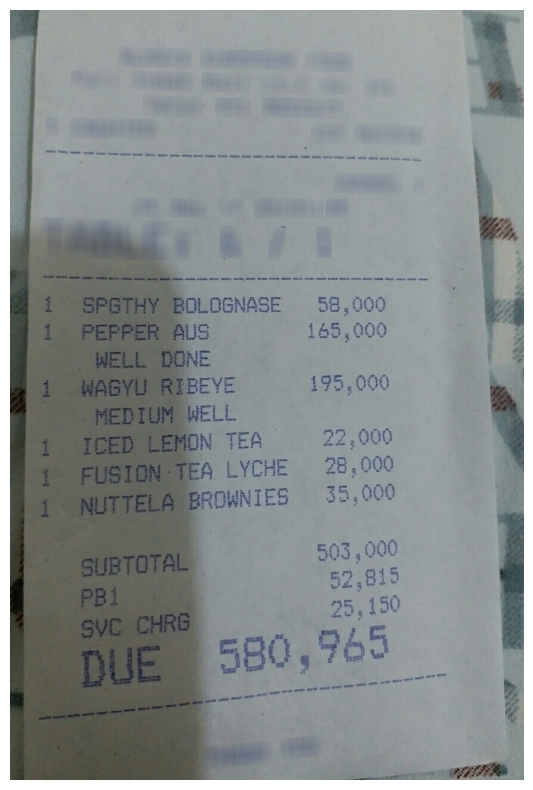

In [21]:
img=cv2.imread(str(train_images[0]))

img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,10))

plt.imshow(img)

plt.axis("off")

In [13]:
with open(train_labels[0]) as f:

    annotation=json.load(f)
annotation.keys()

dict_keys(['dontcare', 'valid_line', 'meta', 'roi', 'repeating_symbol'])

In [25]:
print(img.shape)
print(gray.shape)

(1296, 864, 3)
(1296, 864)
